# [프로젝트] 요소수 유통 주유소 재고 현황 데이터 분석

---

## 프로젝트 목표
---
- 요소수 유통 주유소 재고 현황 데이터를 살펴보고 유의미한 데이터를 불러옵니다.
- 데이터를 지도에 표출하여 요소수 재고 현황을 조회할 수 있는 서비스를 제작합니다.

## 프로젝트 목차
---
1. **데이터 불러오기:** csv 데이터를 불러온 후 Dataframe 구조를 확인합니다.
2. **데이터 전처리하기:** 유의미한 데이터를 제공하기 위해 데이터를 전처리합니다.
3. **데이터 분석하기:** 다양한 방법으로 데이터를 파헤치고 통계해봅니다.
4. **데이터 시각화하기:** 지도에 데이터를 표출하여 요소수 재고 현황 조회 서비스를 제공합니다.

## 프로젝트 개요
---
현재 사회적 문제로 대두되고 있는 요소수 문제를 극복하기 위해 공공데이터 포털에서 요소수 유통 주유소 재고현황을 제공하고 있습니다.

본 실습을 통해 요소수 재고 현황 데이터를 지도에 표출하여 유의미한 데이터를 제공하는 서비스를 구축해봅니다.

**데이터 출처:** https://www.data.go.kr/index.do

---

## 1. 데이터 불러오기

pandas Dataframe 형태로 요소수 재고 현황 데이터를 불러들입니다.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 필요한 라이브러리 불러오기
import numpy as np
import pandas as pd
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/'

# 데이터 불러오기
df = pd.read_csv(DATA_PATH + "./Urea data.csv")
df

,addr,code,color,inventory,lat,lng,name,openTime,price,regDt,tel
0,경기 광명시 오리로 608 (소하동),A0000004,GREEN,1700,37.456201,126.880407,(주)지에스이앤알 직영 하안단지주유소,NaN,2000,2021-12-28 10:23:15,02-899-5202
1,경기 용인시 기흥구 흥덕중앙로 92,A0000012,GREEN,3228,37.275967,127.077150,(주)지에스이앤알 흥덕주유소,NaN,2000,2021-12-28 06:06:12,031-215-8053
2,충남 부여군 내산면 서천공주고속도로 26,A0000052,GRAY,0,36.258064,126.800203,부여백제(공주)주유/충전소,NaN,1500,2021-12-28 11:11:38,041-833-8300
3,충남 공주시 당진영덕고속도로 72-1,A0000053,YELLOW,791,36.497380,127.168437,공주(대전)휴게소 주유소,NaN,1000,2021-12-28 09:01:09,041-854-9728
4,충남 공주시 의당면 당진영덕고속도로 69,A0000054,YELLOW,762,36.498579,127.165047,공주(당진)휴게소주유소/충전소,NaN,1000,2021-12-28 13:56:33,041-854-9504
...,...,...,...,...,...,...,...,...,...,...,...
195,인천 서구 중봉대로 148,A0008072,GREEN,2510,37.492677,126.648296,한밭산업㈜ 청라주유소,NaN,1500,2021-12-28 12:02:05,032-575-5261
196,인천 서구 봉수대로 1543 (금곡동),A0008107,YELLOW,972,37.609760,126.643827,(주)디오티디 인천랍스터주유소,NaN,2000,2021-12-28 11:19:25,032-567-5185
197,경기 의왕시 오봉로 182 (부곡동),A0008150,GREEN,1912,37.334862,126.960332,현대오일뱅크(주)직영 의왕셀프주유소,NaN,2000,2021-12-28 09:08:34,031-461-8204
198,경기 의왕시 창말로 39,A0008176,YELLOW,200,37.336115,126.953993,의왕아이시디주유소,"08:00~20:00(평일), 08:00~16:00(토)일요일휴무",1500,2021-12-28 11:13:41,031-461-8005


불러온 데이터를 살펴보면 200개의 요소수 유통 주유소에 대한 11개의 정보가 있습니다.

각 컬럼은 왼쪽부터 `주소`, `주유소 코드`, `재고 레벨`, `재고`, `위도`, `경도`, `영업시간`, `가격`, `업데이트 일시`, 그리고 `전화번호`에 대한 정보를 가지고 있습니다.

---

## 2. 데이터 전처리하기

다음으로 데이터에 결측치(missing data)가 있는지 확인하고, 데이터 정제 과정을 수행해 봅시다.

In [ ]:
df.info() # 데이터 구조 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   addr       200 non-null    object 
 1   code       200 non-null    object 
 2   color      200 non-null    object 
 3   inventory  200 non-null    int64  
 4   lat        200 non-null    float64
 5   lng        200 non-null    float64
 6   name       200 non-null    object 
 7   openTime   13 non-null     object 
 8   price      200 non-null    int64  
 9   regDt      200 non-null    object 
 10  tel        200 non-null    object 
dtypes: float64(2), int64(2), object(7)
memory usage: 17.3+ KB


데이터 구조를 살펴보면 `영업시간` 대한 정보에 결측치가 있는 것을 알 수 있습니다. 이는 `영업시간`에 대한 정보가 존재하지 않는 다는 것을 의미합니다.

비어있는 열에서는 유의미한 정보를 얻을 수 없기 때문에 `df.drop()`을 사용하여 해당 데이터를 삭제합니다.

In [ ]:
df = df.drop('openTime', axis=1)
df

,addr,code,color,inventory,lat,lng,name,price,regDt,tel
0,경기 광명시 오리로 608 (소하동),A0000004,GREEN,1700,37.456201,126.880407,(주)지에스이앤알 직영 하안단지주유소,2000,2021-12-28 10:23:15,02-899-5202
1,경기 용인시 기흥구 흥덕중앙로 92,A0000012,GREEN,3228,37.275967,127.077150,(주)지에스이앤알 흥덕주유소,2000,2021-12-28 06:06:12,031-215-8053
2,충남 부여군 내산면 서천공주고속도로 26,A0000052,GRAY,0,36.258064,126.800203,부여백제(공주)주유/충전소,1500,2021-12-28 11:11:38,041-833-8300
3,충남 공주시 당진영덕고속도로 72-1,A0000053,YELLOW,791,36.497380,127.168437,공주(대전)휴게소 주유소,1000,2021-12-28 09:01:09,041-854-9728
4,충남 공주시 의당면 당진영덕고속도로 69,A0000054,YELLOW,762,36.498579,127.165047,공주(당진)휴게소주유소/충전소,1000,2021-12-28 13:56:33,041-854-9504
...,...,...,...,...,...,...,...,...,...,...
195,인천 서구 중봉대로 148,A0008072,GREEN,2510,37.492677,126.648296,한밭산업㈜ 청라주유소,1500,2021-12-28 12:02:05,032-575-5261
196,인천 서구 봉수대로 1543 (금곡동),A0008107,YELLOW,972,37.609760,126.643827,(주)디오티디 인천랍스터주유소,2000,2021-12-28 11:19:25,032-567-5185
197,경기 의왕시 오봉로 182 (부곡동),A0008150,GREEN,1912,37.334862,126.960332,현대오일뱅크(주)직영 의왕셀프주유소,2000,2021-12-28 09:08:34,031-461-8204
198,경기 의왕시 창말로 39,A0008176,YELLOW,200,37.336115,126.953993,의왕아이시디주유소,1500,2021-12-28 11:13:41,031-461-8005


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   addr       200 non-null    object 
 1   code       200 non-null    object 
 2   color      200 non-null    object 
 3   inventory  200 non-null    int64  
 4   lat        200 non-null    float64
 5   lng        200 non-null    float64
 6   name       200 non-null    object 
 7   price      200 non-null    int64  
 8   regDt      200 non-null    object 
 9   tel        200 non-null    object 
dtypes: float64(2), int64(2), object(6)
memory usage: 15.8+ KB


이제 `영업시간` 데이터가 삭제된 것을 확인할 수 있습니다.

이번에는 이상치가 있는지 살펴보겠습니다. `inventory`와 `price` 두 변수에 대해 진행해봅시다.

In [ ]:
inven_mean = df['inventory'].mean()
print(f"재고량 평균은 {inven_mean:.2f}개") # 문자열 포맷팅

재고량 평균은 1371.32개


In [ ]:
# 재고량이 가장 적은 관측값들
df['inventory'].sort_values()[:5]

,inventory
2,0
22,0
47,0
70,0
114,0


In [ ]:
# 재고량이 가장 많은 관측값들
df['inventory'].sort_values()[-5:]

,inventory
90,4000
168,4000
28,4900
33,5210
183,6900


음수의 값을 가진다거나, 터무니 없이 큰 값을 가지는 케이스는 우선 없는 것 같습니다.

In [ ]:
price_mean = df['price'].mean()
print(f"가격 평균은 {price_mean:.2f}원") # 문자열 포맷팅

가격 평균은 1738.50원


In [ ]:
# 가격이 가장 낮은 관측값들
df['price'].sort_values()[:5]

,price
3,1000
4,1000
59,1000
47,1000
20,1200


In [ ]:
# 가격이 가장 높은 관측값들
df['price'].sort_values()[-5:]

,price
36,2400
191,2500
169,2500
14,3000
152,3000


요소수 가격은 1000원에서 3000원 사이에 꽤 고르게 분포하고 있는 것을 알 수 있습니다. <br>
이 경우에도 별다른 이상치는 없는 것으로 보이므로, 본격적인 분석 단계로 넘어가겠습니다.

---

## 3. 데이터 분석하기

`matplotlib`과 `seaborn` 라이브러리를 이용하여 데이터 통계를 해봅시다.

In [ ]:
# 필요한 라이브러리 불러오기
import matplotlib.pyplot as plt
import seaborn as sns

### 3-1. 지역별 요소수 유통 주유소 분포 알아보기

먼저 `전화번호` 정보를 활용하여 지역별 요소수 유통 주유소의 분포를 알아봅시다.

국내 지역번호 리스트를 생성하고 `전화번호` 데이터를 기반으로 각 지역의 요소수 유통 주유소의 수를 알아봅시다.

In [ ]:
# 국내 지역번호 리스트 생성
list_tel = ['02', '031', '032', '033', '041', '042', '043', '044', '051', '052', '053', '054', '055', '061', '062', '063', '064']
df_region_by_tel = pd.Series(np.zeros(len(list_tel), dtype=np.int64), index=list_tel)

# 지역별 요소수 유통 주유소 수 세기
for i in list_tel:
    df_region_by_tel[i] = df['tel'].str.startswith(i).sum()

df_region_by_tel

,0
02,3
031,148
032,28
033,1
041,10
042,0
043,3
044,0
051,1
052,0


`전화번호` 정보를 살펴보았을 때 대부분의 요소수 유통 주유소는 수도권, 특히 경기도에 밀집되어 있으며 지방에서는 찾기 힘든 것을 확인할 수 있습니다.

추가적으로 주소 (`addr`)을 이용해서도 유사한 분석을 진행해보겠습니다.

In [ ]:
# 문자열을 입력받아 첫번째 단어를 추출하는 간단한 보조함수를 먼저 정의합니다.
def extract(string):
    return string.split()[0] # 띄어쓰기를 기준으로 'split'

In [ ]:
addrs = df['addr'].apply(extract)
addrs

,addr
0,경기
1,경기
2,충남
3,충남
4,충남
...,...
195,인천
196,인천
197,경기
198,경기


In [ ]:
addrs_cnt = addrs.value_counts().sort_values(ascending=False)
addrs_cnt

,count
addr,
경기,144
인천,25
충남,10
경기도,6
전북,3
충북,3
경북,2
평택시,2
부산,1


In [ ]:
addrs_cnt_df = pd.DataFrame(addrs_cnt).rename(columns={'addr':'counts'})
addrs_cnt_df

,count
addr,
경기,144
인천,25
충남,10
경기도,6
전북,3
충북,3
경북,2
평택시,2
부산,1


`인천`과 `인천광역시`가 데이터 수집 과정에서의 오류로 중복 기재되었으므로, 손으로 직접 처리해줍니다. <br>
`경기도`와 `경기`도 비슷한 방법으로 진행해줍니다.

In [ ]:
# 두 row의 인덱스 값을 입력받아, 첫번째 인덱스로 병합하는 간단한 보조함수를 정의합니다.
def merge_rows(df, rowA, rowB):
    cnt = df.loc[rowB]
    df.loc[rowA] += cnt
    df = df.drop(rowB)
    return df

In [ ]:
addrs_cnt_df = merge_rows(addrs_cnt_df, '인천', '인천광역시')
addrs_cnt_df

,count
addr,
경기,144
인천,26
충남,10
경기도,6
전북,3
충북,3
경북,2
평택시,2
부산,1


In [ ]:
addrs_cnt_df = merge_rows(addrs_cnt_df, '경기', '경기도')
addrs_cnt_df

,count
addr,
경기,150
인천,26
충남,10
전북,3
충북,3
경북,2
평택시,2
부산,1
서울,1


`평택시`의 경우도 경기도의 일부로 분류되는 것이 옳겠으나, 데이터 수집 과정에서 노이즈가 들어간 경우라고 볼 수 있겠습니다. <br>
분석 필요에 따라 이 부분도 위와 같이 처리해줄 수 있겠습니다.

---

### 3-2. 요소수 재고 레벨 분포 알아보기

전국의 요소수 `재고량`의 분포를 `histogram`을 통해 알아봅시다.

Text(0, 0.5, 'count')

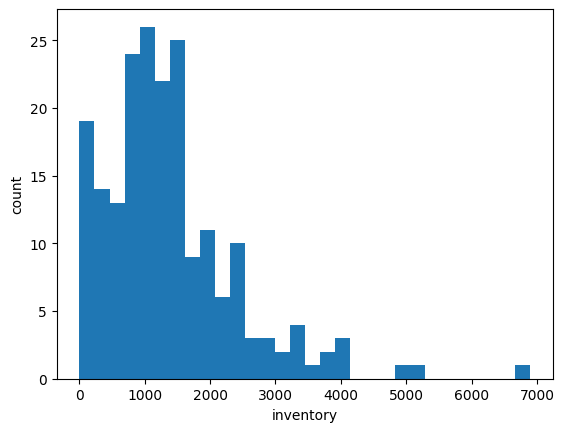

In [ ]:
fig, ax = plt.subplots()
ax.hist(df['inventory'], bins=30)
ax.set_xlabel('inventory')
ax.set_ylabel('count')

위의 `histogram`을 살펴보면 `재고량`이 왼쪽에 많이 분포되어 있는 것을 확인할 수 있습니다.

`재고량` 데이터를 `boxplot`으로도 확인해 보고, 평균 `재고량`도 계산해 봅시다.

요소수 재고량의 평균은 1371.315개입니다.


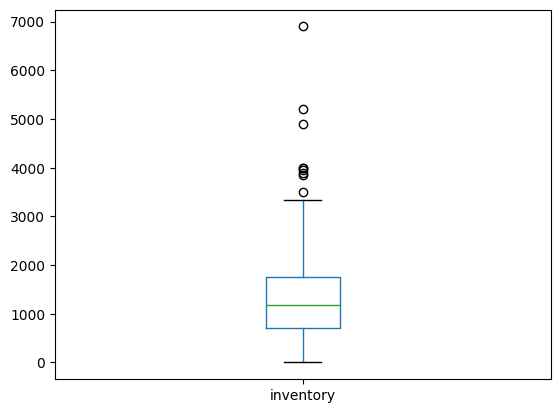

In [ ]:
df.boxplot(column='inventory', grid=False) # boxplot 생성

inven_mean = df['inventory'].mean() # 평균값 계산
print(f"요소수 재고량의 평균은 {inven_mean}개입니다.") # 문자열 포맷팅

요소수의 평균 재고량은 `1371.315`입니다.

위의 두 그래프만 봤을 때는 요소수 재고가 부족한 것처럼 보입니다. 요소수 `재고 레벨`을 막대그래프로 그려보고 재고 현황을 좀 더 파헤쳐 봅시다.

/tmp/ipykernel_966/921622446.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='color', data=df, palette=['#8FBC8B', '#F0E68C', '#FA8072', '#C0C0C0'], order=['GREEN', 'YELLOW', 'RED', 'GRAY'])


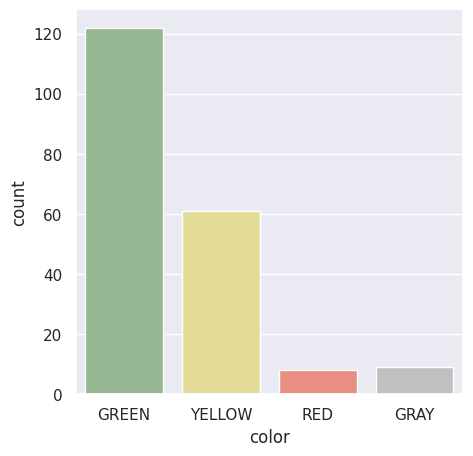

In [ ]:
plt.figure(figsize=(5,5))
sns.set(style='darkgrid')
ax = sns.countplot(x='color', data=df, palette=['#8FBC8B', '#F0E68C', '#FA8072', '#C0C0C0'], order=['GREEN', 'YELLOW', 'RED', 'GRAY'])

`GREEN`은 여유, `YELLOW`는 보통, `RED`는 부족, `GRAY`는 품절은 의미합니다.

위의 그래프를 보았을 때는 요소수 재고가 여유있는 것을 알 수 있습니다. 실제로 `재고량`이 `1000` 이상이면 `GREEN`으로 분류되기 때문에 요소수 재고는 여유있는 것입니다.

---

### 3-3. 요소수 가격 분포 알아보기

앞서 사용한 방법과 마찬가지로 `histogram`을 통해 요소수 `가격`의 분포를 알아봅시다.

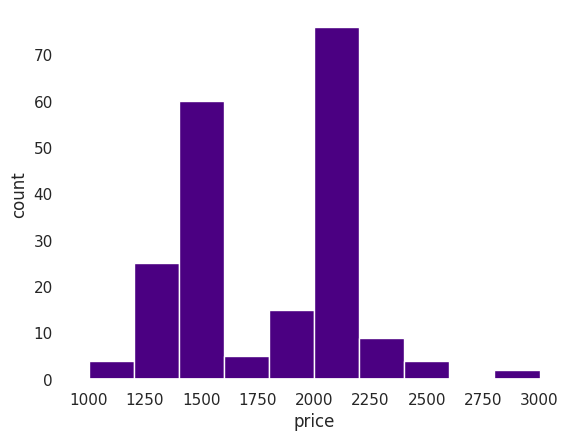

In [ ]:
fig, ax = plt.subplots()
ax.hist(df['price'], bins=10, color='indigo')
ax.set_xlabel('price')
ax.set_ylabel('count')
ax.set_facecolor('white')

`가격` 데이터를 `boxplot`으로도 확인해 봅시다. 요소수의 평균 가격도 알아봅시다.

요소수 가격의 평균은 1738.5원입니다.


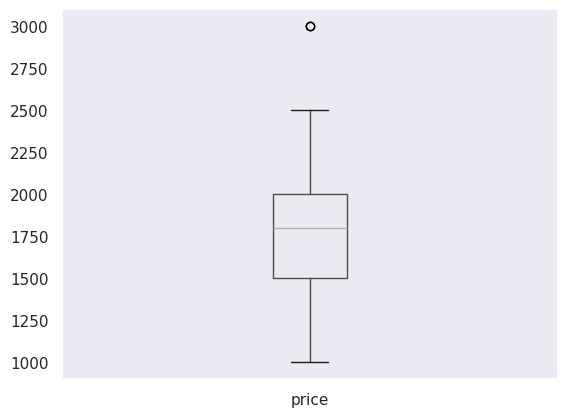

In [ ]:
df.boxplot(column='price', grid=False) # boxplot 생성

price_mean = df['price'].mean() # 평균값 계산
print(f"요소수 가격의 평균은 {price_mean:.1f}원입니다.") # 문자열 포맷팅

요소수의 평균 가격은 `1738.5`원인 것을 확인하였습니다.

---

### 3-4. 요소수 가격과 재고의 상관관계 알아보기

이번에는 `scatterplot`을 이용하여 주유소 별 요소수 가격과 재고량 사이에 상관관계가 있는지 알아보겠습니다.

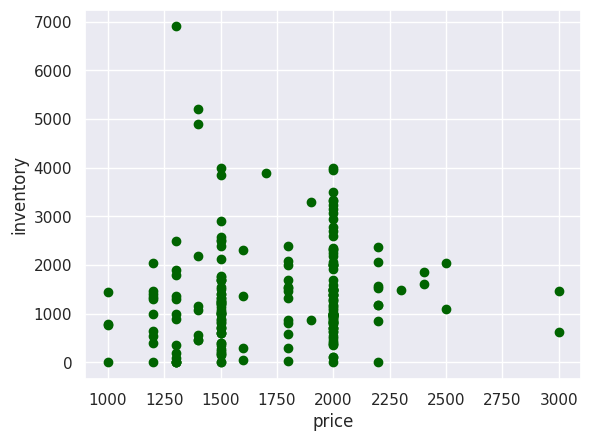

In [ ]:
fig, ax = plt.subplots()
ax.scatter(df['price'], df['inventory'], color='darkgreen')
ax.set_xlabel('price')
ax.set_ylabel('inventory')
plt.show()

이번에는 `pandas`의 `corr` 함수를 이용해서 가격과 재고량 사이의 통계적 상관관계를 확인해보겠습니다.

In [ ]:
corr = df.corr(method="pearson", numeric_only=True)["inventory"][
    "price"
]  # 피어슨 상관계수
print(
    f"가격과 재고량 사이의 피어슨 상관계수는 {corr:.3f}입니다."
)  # 문자열 포맷팅

가격과 재고량 사이의 피어슨 상관계수는 0.099입니다.


관점에 따라 다르겠지만, 충분히 유의미한 선형 상관관계를 보인다고 말하기는 어렵겠습니다.

---

### 3-5. 주유소 이름에서 패턴 찾아보기

지금까지 가격이나 재고량과 같이 분석이 상대적으로 쉬운 변량들을 주로 다뤄봤습니다. <br>
이번에는 주유소의 이름에서 패턴을 추출하는 조금 더 창의적인 분석을 시도해보겠습니다.

분석에 앞서 분석을 도와줄 보조함수를 두 가지 정의하겠습니다. <br>
여러 카테고리에 대해 유사한 분석을 진행할 때 이와 같이 관련 함수를 미리 정의해두면 수고를 줄일 수 있습니다.

In [ ]:
# 분석 키워드와 가격 차이를 입력값으로 받아, 전체 평균과 비교해주는 함수를 정의합니다.
def price_insight(keyword, diff):
    if diff > 0:
        print(f"{keyword} 주유소의 요소수 가격은 전체 평균에 비해 {diff:.2f}원 저렴합니다.")
    else:
        print(f"{keyword} 주유소의 요소수 가격은 전체 평균에 비해 {-diff:.2f}원 비쌉니다.")

In [ ]:
# 분석 키워드와 재고량 차이를 입력값으로 받아, 전체 평균과 비교해주는 함수를 정의합니다.
def inven_insight(keyword, diff):
    if diff > 0:
        print(f"{keyword} 주유소의 요소수 재고량은 전체 평균에 비해 {diff:.2f}만큼 적습니다.")
    else:
        print(f"{keyword} 주유소의 요소수 재고량은 전체 평균에 비해 {-diff:.2f}만큼 많습니다.")

먼저 휴게소에 속해있는 주유소들을 살펴보겠습니다.

In [ ]:
tdf = df[df.name.str.contains('휴게소')]
tdf

,addr,code,color,inventory,lat,lng,name,price,regDt,tel
3,충남 공주시 당진영덕고속도로 72-1,A0000053,YELLOW,791,36.497380,127.168437,공주(대전)휴게소 주유소,1000,2021-12-28 09:01:09,041-854-9728
4,충남 공주시 의당면 당진영덕고속도로 69,A0000054,YELLOW,762,36.498579,127.165047,공주(당진)휴게소주유소/충전소,1000,2021-12-28 13:56:33,041-854-9504
180,경기 용인시 처인구 이동면 남북대로 2616,A0007236,GRAY,0,37.140624,127.205600,송전휴게소주유소/충전소,1500,2021-12-28 14:12:48,031-335-4194


In [ ]:
price_diff = df.price.mean() - tdf.price.mean() # 전체 평균과의 요소수 가격 차이
price_insight("휴게소", price_diff)

휴게소 주유소의 요소수 가격은 전체 평균에 비해 571.83원 저렴합니다.


In [ ]:
inven_diff = df.inventory.mean() - tdf.inventory.mean() # 전체 평균과의 요소수 가격 차이
inven_insight("휴게소", inven_diff)

휴게소 주유소의 요소수 재고량은 전체 평균에 비해 853.65만큼 적습니다.


일반화하기에는 관측값이 부족하긴 하지만, 휴게소의 주유소들의 경우 요소수 가격은 더 저렴하고 대신 재고량도 부족한 경향이 있는 것 같습니다.

이번에는 "셀프" 주유소들을 살펴보겠습니다.

In [ ]:
tdf = df[df.name.str.contains('셀프')]
print(f"셀프 주유소 관측값 수: {tdf.shape[0]}")
tdf.head()

셀프 주유소 관측값 수: 15


,addr,code,color,inventory,lat,lng,name,price,regDt,tel
40,경기 평택시 경기대로 1078 (장당동),A0002027,YELLOW,800,37.042878,127.062331,동일석유(주) 금성셀프주유소,1800,2021-12-28 12:55:53,031-665-0190
57,경기 용인시 처인구 백암면 죽양대로 1454,A0002375,YELLOW,370,37.173587,127.347521,백암셀프주유소,2000,2021-12-28 11:03:51,031-337-2066
64,경기 화성시 우정읍 포승향남로 976,A0002627,GREEN,2241,37.036550,126.806016,(주)소모에너지 우정셀프주유소,2000,2021-12-28 10:45:28,031-8055-0973
76,경기 평택시 현덕면 서해로 471,A0002967,GREEN,1900,36.942756,126.914171,기산셀프주유소,1300,2021-12-28 10:31:18,031-684-0099
87,경기 안성시 원곡면 남북대로 1106,A0003290,GREEN,2943,37.037843,127.151106,삼미상사(주) 서안성셀프주유소,2000,2021-12-28 12:15:28,031-652-5210


In [ ]:
price_diff = df.price.mean() - tdf.price.mean() # 전체 평균과의 요소수 가격 차이
price_insight('셀프', price_diff)

셀프 주유소의 요소수 가격은 전체 평균에 비해 208.17원 비쌉니다.


셀프 주유소가 더 저렴할 것이라는 일반적인 인식과는 달리, "요소수 가격" 측면에서는 그런 추세가 관측되지 않는군요.

In [ ]:
inven_diff = df.inventory.mean() - tdf.inventory.mean() # 전체 평균과의 요소수 가격 차이
inven_insight('셀프', inven_diff)

셀프 주유소의 요소수 재고량은 전체 평균에 비해 121.88만큼 많습니다.


가격이 더 비싸서인지는 모르겠지만, 재고량은 더 많은 편입니다.

마지막으로 이름에 "알뜰"이 들어간 주유소들이 실제로 더 알뜰할지 살펴보겠습니다.

In [ ]:
tdf = df[df.name.str.contains('알뜰')]
print(f"알뜰 주유소 관측값 수: {tdf.shape[0]}")
tdf.head()

알뜰 주유소 관측값 수: 3


,addr,code,color,inventory,lat,lng,name,price,regDt,tel
20,인천 중구 인중로 180,A0001327,GREEN,1400,37.468916,126.624263,알뜰 부광주유소,1200,2021-12-28 10:52:50,032-765-5145
107,경기 여주시 점동면 장여로 931,A0003901,GREEN,1374,37.183854,127.662086,덕평알뜰주유소,1600,2021-12-28 14:49:44,031-882-7338
140,경기 양주시 부흥로 1300,A0005003,GREEN,3890,37.787343,127.020032,(주)어하둥둥알뜰주유소,1700,2021-12-28 08:20:54,031-826-5182


In [ ]:
price_diff = df.price.mean() - tdf.price.mean() # 전체 평균과의 요소수 가격 차이
price_insight("알뜰", price_diff)

알뜰 주유소의 요소수 가격은 전체 평균에 비해 238.50원 저렴합니다.


역시 관측값이 충분하지는 않지만, 이 데이터에 따르면 알뜰 주유소의 요소수 가격은 평균보다 저렴한 편입니다.

---

## 4. 데이터 시각화하기

### 4-1. 지역별 요소수 재고 현황 지도에 나타내기

folium 라이브러리를 이용하여 요소수 재고 현황을 지도에 표출합니다.

In [ ]:
# folium 라이브러리 불러오기
!pip install folium
import folium

In [ ]:
# 서울 중심지 중구를 가운데 좌표로 잡아 지도를 출력합니다
map_osm = folium.Map(location=[37.557945, 126.99419], zoom_start=10)
map_osm

요소수 재고 현황을 확인하고자 하는 지역을 `target_region`으로 설정합니다.

본 실습에서는 경기도의 요소수 재고 현황을 알아보겠습니다.

In [ ]:
# 요소수 유통 주유소를 찾고 싶은 지역을 설정합니다.
target_region = '경기' # 변경 가능

주소에 `target_region`이 포함된 정보를 찾아 Dataframe 형태로 불러옵니다.

In [ ]:
df_target_region = df[df['addr'].str.contains(target_region)]
df_target_region

,addr,code,color,inventory,lat,lng,name,price,regDt,tel
0,경기 광명시 오리로 608 (소하동),A0000004,GREEN,1700,37.456201,126.880407,(주)지에스이앤알 직영 하안단지주유소,2000,2021-12-28 10:23:15,02-899-5202
1,경기 용인시 기흥구 흥덕중앙로 92,A0000012,GREEN,3228,37.275967,127.077150,(주)지에스이앤알 흥덕주유소,2000,2021-12-28 06:06:12,031-215-8053
6,경기 안양시 만안구 엘에스로 237 (안양동),A0000215,GREEN,1610,37.379715,126.938793,마하주유소,2400,2021-12-28 08:33:03,031-444-5175
8,경기 용인시 처인구 이동면 어진로 637,A0000269,GREEN,1000,37.107869,127.178377,남사IC주유소,1500,2021-12-28 10:32:10,031-336-5145
13,경기 파주시 탄현면 새오리로,A0000695,GREEN,1260,37.787836,126.688009,성동IC주유소,1500,2021-12-28 11:04:06,031-944-4651
...,...,...,...,...,...,...,...,...,...,...
190,경기 광주시 곤지암읍 경충대로 41,A0007819,YELLOW,979,37.328131,127.394930,서민행복주유소,2000,2021-12-28 12:01:50,031-761-1775
191,경기 김포시 통진읍 김포대로 2466,A0007889,GREEN,1092,37.698199,126.575722,펜텍주유소,2500,2021-12-28 12:31:17,031-997-5150
197,경기 의왕시 오봉로 182 (부곡동),A0008150,GREEN,1912,37.334862,126.960332,현대오일뱅크(주)직영 의왕셀프주유소,2000,2021-12-28 09:08:34,031-461-8204
198,경기 의왕시 창말로 39,A0008176,YELLOW,200,37.336115,126.953993,의왕아이시디주유소,1500,2021-12-28 11:13:41,031-461-8005


In [ ]:
df_target_region.shape # target_region이 포함된 관측값의 갯수

(150, 10)

이제 원하는 지역의 요소수 재고 현황을 시각화 해봅시다.

1. 지도에 표출할 내용은 주유소 명칭, 주소, 재고량, 전화번호입니다.
2. `lat`, `lng` 정보를 이용해 지도 상의 좌표를 가져옵니다.
3. 재고에 따라 지도에 표출할 마커의 색상을 정합니다.
4. `CircleMarker`를 이용해 마커를 생성합니다.

In [ ]:
map_osm = folium.Map(location=[37.557945, 126.99419], zoom_start=9)

for i in df_target_region.values:
    iframe = "<b>    명칭 : </b>"+str(i[6])+"<br>"+"<b>     주소 : </b>"+i[0]+"<br>"+"<b> 재고량 : </b>"+str(i[3])+"<br>"+"<b> 전화번호 : </b>"+str(i[8])
    popup = folium.Popup(iframe, min_width=300, max_width=800)

    # 요소수 재고에 따라 지도에 나타낼 마커의 색상을 정합니다.
    color = i[2].upper()
    if color == 'GREEN':
        color_code = '#9ACD32'
    elif color == 'YELLOW':
        color_code = '#FFFF00'
    elif color ==  'RED':
        color_code = '#DC143C'
    elif color == 'GRAY':
        color_code = '#696969'

    # CircleMarker를 사용하여 원하는 지역에 마커를 생성합니다.
    marker = folium.CircleMarker([i[4], i[5]],          # 위치
                                 radius=5,              # 범위
                                 color=color_code,      # 색상
                                 fill=True,            # 마커 채우기
                                 fill_opacity=1.0,
                                 popup=popup)           # 팝업 설정
    marker.add_to(map_osm)
map_osm

데이터를 시각화해보니 요소수 재고는 경기도 여러 지역에 골고루 분포되어 있는 것을 확인할 수 있습니다. `GREEN`과 `YELLOW` 마커가 분산되어 있기 때문입니다.

하지만 일부 주유소는 요소수가 매진되었거나 부족한 것으로 보입니다.

유사한 분석을 **가격**에 대해 진행해보겠습니다.

In [ ]:
map_osm = folium.Map(location=[37.557945, 126.99419], zoom_start=9)

for i in df_target_region.values:
    iframe = "<b>    명칭 : </b>"+str(i[6])+"<br>"+"<b>     주소 : </b>"+i[0]+"<br>"+"<b> 재고량 : </b>"+str(i[3])+"<br>"+"<b> 전화번호 : </b>"+str(i[8])
    popup = folium.Popup(iframe, min_width=300, max_width=800)

    # 요소수 가격에 따라 지도에 나타낼 마커의 색상을 정합니다.
    price = i[7]
    if price <= 1500:
        color_code = '#f9d71c'
    elif price <= 2000:
        color_code = '#ff6600'
    else:
        color_code = '#ff0000'

    # CircleMarker를 사용하여 원하는 지역에 마커를 생성합니다.
    marker = folium.CircleMarker([i[4], i[5]],          # 위치
                                 radius=5,              # 범위
                                 color=color_code,      # 색상
                                 fill=True,            # 마커 채우기
                                 fill_opacity=1.0,
                                 popup=popup)           # 팝업 설정
    marker.add_to(map_osm)
map_osm

---

### 4-2. 재고별 요소수 유통 주유소 지도에 나타내기

다음으로 요소수 재고가 있는 주유소를 찾아봅시다.
재고량을 나타내는 `target_color`를 설정합니다.

In [ ]:
# 재고량을 충분으로 설정
target_color = 'GREEN'

In [ ]:
df_target_color = df[df['color'].str.contains(target_color)]
df_target_color

,addr,code,color,inventory,lat,lng,name,price,regDt,tel
0,경기 광명시 오리로 608 (소하동),A0000004,GREEN,1700,37.456201,126.880407,(주)지에스이앤알 직영 하안단지주유소,2000,2021-12-28 10:23:15,02-899-5202
1,경기 용인시 기흥구 흥덕중앙로 92,A0000012,GREEN,3228,37.275967,127.077150,(주)지에스이앤알 흥덕주유소,2000,2021-12-28 06:06:12,031-215-8053
5,전북 진안군 진안읍 익산장수고속도로 42-1,A0000057,GREEN,1700,35.774848,127.426593,한화리조트(주)진안(하)주유소,1500,2021-12-28 01:45:01,063-432-6353
6,경기 안양시 만안구 엘에스로 237 (안양동),A0000215,GREEN,1610,37.379715,126.938793,마하주유소,2400,2021-12-28 08:33:03,031-444-5175
8,경기 용인시 처인구 이동면 어진로 637,A0000269,GREEN,1000,37.107869,127.178377,남사IC주유소,1500,2021-12-28 10:32:10,031-336-5145
...,...,...,...,...,...,...,...,...,...,...
192,인천 서구 백범로 853 (가좌동),A0007908,GREEN,1000,37.484730,126.663354,(주)보문 가좌주유소,1200,2021-12-28 11:52:26,032-583-5188
194,인천 서구 중봉대로 372 (원창동),A0007974,GREEN,1756,37.512512,126.649565,서광유업㈜청도3주유소,1500,2021-12-28 13:45:00,032-577-0001
195,인천 서구 중봉대로 148,A0008072,GREEN,2510,37.492677,126.648296,한밭산업㈜ 청라주유소,1500,2021-12-28 12:02:05,032-575-5261
197,경기 의왕시 오봉로 182 (부곡동),A0008150,GREEN,1912,37.334862,126.960332,현대오일뱅크(주)직영 의왕셀프주유소,2000,2021-12-28 09:08:34,031-461-8204


In [ ]:
# 전국의 요소수 주유소 재고를 확인하기 위해 중심지 좌표와 지도의 크기를 조절합니다.
map_osm = folium.Map(location=[36.3504, 127.3845], zoom_start=7)

for i in df_target_color.values:
    iframe = "<b>    명칭 : </b>"+str(i[6])+"<br>"+"<b>     주소 : </b>"+i[0]+"<br>"+"<b> 재고량 : </b>"+str(i[3])+"<br>"+"<b> 전화번호 : </b>"+str(i[8])
    popup = folium.Popup(iframe, min_width=300, max_width=800)

    # CircleMarker를 사용하여 원하는 지역에 마커를 생성합니다.
    marker = folium.CircleMarker([i[4], i[5]],          # 위치
                                 radius=5,              # 범위
                                 color='#9ACD32',       # 색상 (본 실습에서는 재고에 따라 색상을 바꾸지 않아도 괜찮습니다)
                                 fill=True,            # 마커 채우기
                                 fill_opacity=1.0,
                                 popup=popup)           # 팝업 설정
    marker.add_to(map_osm)
map_osm

지도를 보면 요소수 재고는 수도권에 많이 남아있은 것을 알 수 있습니다. 지방에서는 `marker`를 찾기 어렵습니다.

이는 위의 `전화번호` 데이터에서 알아봤듯이 수도권 밖의 지역에 요소수 주유소가 적다는 사실과도 관련이 있습니다.

---

<span style="color:rgb(120, 120, 120)">본 학습 자료를 포함한 사이트 내 모든 자료의 저작권은 엘리스에 있으며 외부로의 무단 복제, 배포 및 전송을 불허합니다.

Copyright @ elice all rights reserved</span>

In [ ]:
import pandas as pd
import folium
from folium.plugins import HeatMap, MarkerCluster

# 1. 가상의 데이터셋 (사용자님의 데이터프레임 변수명으로 변경 가능)
data = {
    'station_name': ['서울주유소', '경기주유소', '인천주유소', '부산주유소', '대구주유소', '광주주유소'],
    'latitude': [37.5665, 37.4138, 37.4563, 35.1796, 35.8714, 35.1595],
    'longitude': [126.9780, 127.5183, 126.7052, 129.0756, 128.6014, 126.8526],
    'inventory': [5000, 4500, 4000, 800, 600, 500]
}
df = pd.DataFrame(data)

# 2. 대한민국 중심부 기준 지도 생성
m = folium.Map(location=[36.5, 127.5], zoom_start=7)

# 3. 마커 클러스터 추가
marker_cluster = MarkerCluster().add_to(m)
for idx, row in df.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=f"{row['station_name']}<br>재고량: {row['inventory']}L",
        icon=folium.Icon(color='blue')
    ).add_to(marker_cluster)

# 4. 히트맵 추가 (재고량 반영)
heat_data = [[row['latitude'], row['longitude'], row['inventory']] for idx, row in df.iterrows()]
HeatMap(heat_data, radius=25, blur=15, max_zoom=1).add_to(m)

# 5. [수정] 파일 저장 대신 화면에 바로 출력!
m

In [ ]:
import json
import pandas as pd
import folium
from folium import DivIcon
import requests

# ==============================================================================
# 1. 종합 데이터셋 정의 (주유소 데이터)
# ==============================================================================
integrated_data = {
    'station_name': [
        '서울 강남 SK', '서울 서초 GS', '서울 송파 현대', '서울 마포 S-OIL', '서울 영등포 알뜰',
        '경기 수원 SK', '경기 성남 GS', '경기 용인 현대', '경기 고양 S-OIL', '경기 안산 알뜰',
        '인천 중구 GS', '인천 남동 SK', '인천 서구 현대', '부산 사하 SK', '부산 강서 GS', '부산 해운대 현대',
        '대구 북구 S-OIL', '대구 달서 알뜰', '광주 광산 SK', '광주 북구 GS', '대전 유성 현대', '대전 중구 S-OIL',
        '울산 남구 SK', '울산 울주 현대', '세종 세종 알뜰', '세종 반곡 GS', '강원 원주 SK', '강원 춘천 S-OIL',
        '충북 청주 GS', '충북 충주 현대', '충남 천안 SK', '충남 아산 알뜰', '전북 전주 S-OIL', '전북 익산 GS',
        '전남 목포 현대', '전남 여수 SK', '경북 포항 알뜰', '경북 구미 GS', '경남 창원 SK', '경남 진주 현대',
        '제주 제주 GS', '제주 서귀포 S-OIL'
    ],
    '지역2': [
        '서울', '서울', '서울', '서울', '서울', '경기', '경기', '경기', '경기', '경기',
        '인천', '인천', '인천', '부산', '부산', '부산', '대구', '대구', '광주', '광주',
        '대전', '대전', '울산', '울산', '세종시', '세종시', '강원', '강원', '충북', '충북',
        '충남', '충남', '전북', '전북', '전남', '전남', '경북', '경북', '경남', '경남',
        '제주', '제주'
    ],
    'brand': [
        'SK에너지', 'GS칼텍스', 'HD현대오일뱅크', 'S-OIL', '알뜰주유소', 'SK에너지', 'GS칼텍스', 'HD현대오일뱅크', 'S-OIL', '알뜰주유소',
        'GS칼텍스', 'SK에너지', 'HD현대오일뱅크', 'SK에너지', 'GS칼텍스', 'HD현대오일뱅크', 'S-OIL', '알뜰주유소', 'SK에너지', 'GS칼텍스',
        'HD현대오일뱅크', 'S-OIL', 'SK에너지', 'HD현대오일뱅크', '알뜰주유소', 'GS칼텍스', 'SK에너지', 'S-OIL', 'GS칼텍스', 'HD현대오일뱅크',
        'SK에너지', '알뜰주유소', 'S-OIL', 'GS칼텍스', 'HD현대오일뱅크', 'SK에너지', '알뜰주유소', 'GS칼텍스', 'SK에너지', 'HD현대오일뱅크',
        'GS칼텍스', 'S-OIL'
    ],
    'latitude': [
        37.5665, 37.5500, 37.5100, 37.5600, 37.5200, 37.2636, 37.4200, 37.3200, 37.6500, 37.3100,
        37.4563, 37.4400, 37.5400, 35.1000, 35.1500, 35.1600, 35.8900, 35.8200, 35.1400, 35.1800,
        36.3600, 36.3200, 35.5389, 35.5600, 36.4801, 36.4900, 37.3400, 37.8854, 36.6372, 36.9900,
        36.8151, 36.7800, 35.8242, 35.9400, 34.8160, 34.7600, 36.0190, 36.1200, 35.2281, 35.2100,
        33.4996, 33.2500
    ],
    'longitude': [
        126.9780, 127.0100, 127.1200, 126.9200, 126.9000, 127.0286, 127.1200, 127.0900, 126.8300, 126.8200,
        126.7052, 126.7300, 126.6700, 128.9600, 128.9800, 129.1600, 128.6100, 128.5300, 126.7800, 126.8900,
        127.3500, 127.4200, 129.3114, 129.2400, 127.2890, 127.3100, 127.9200, 127.7300, 127.4897, 127.9200,
        127.1585, 127.0000, 127.1480, 126.9500, 126.4629, 127.6600, 129.3434, 128.3400, 128.6811, 128.1200,
        126.5312, 126.5600
    ],
    'price': [1650, 1590, 1620, 1450, 1420, 1580, 1540, 1560, 1480, 1430, 1490, 1450, 1420, 1680, 1650, 1620, 1620, 1580, 1590, 1550, 1550, 1520, 1610, 1580, 1490, 1520, 1640, 1600, 1580, 1550, 1560, 1530, 1580, 1540, 1630, 1610, 1590, 1560, 1620, 1600, 1690, 1680],
    'inventory': [4500, 3200, 2800, 5100, 4200, 5200, 2100, 1900, 4800, 3500, 3800, 2400, 1500, 450, 600, 800, 120, 900, 600, 1100, 1100, 1300, 950, 1800, 2100, 1450, 300, 950, 850, 1200, 1300, 2100, 500, 1600, 400, 900, 750, 1100, 800, 1400, 250, 450],
    'gas_price': [1685, 1690, 1720, 1640, 1599, 1660, 1645, 1650, 1610, 1585, 1630, 1625, 1595, 1699, 1690, 1710, 1635, 1589, 1620, 1615, 1625, 1599, 1675, 1660, 1580, 1610, 1680, 1645, 1640, 1630, 1635, 1598, 1620, 1610, 1650, 1640, 1615, 1595, 1665, 1650, 1790, 1785],
    'gas_inventory': [25000, 21000, 18000, 32000, 41000, 34000, 28000, 22000, 31000, 45000, 29000, 33000, 42000, 14000, 19000, 15000, 12000, 38000, 26000, 29000, 31000, 34000, 22000, 27000, 48000, 31000, 11000, 23000, 27000, 29000, 32000, 41000, 16000, 28000, 15000, 24000, 36000, 29000, 23000, 26000, 9000, 12000]
}
station_df = pd.DataFrame(integrated_data)

# ==============================================================================
# 2. 신규 확장: 대한민국 모든 핵심 고속도로 노선 네트워크 정의 (상시 고정용)
# ==============================================================================
highways_network = {
    '경부고속도로': [[37.5283, 127.0226], [37.3392, 127.1009], [37.1995, 127.0818], [36.8056, 127.1528], [36.3504, 127.3845], [36.1245, 128.3456], [35.8714, 128.6014], [35.5389, 129.3114], [35.1796, 129.0756]],
    '서해안고속도로': [[37.4294, 126.9022], [37.3115, 126.8322], [36.9610, 126.8220], [36.6512, 126.6801], [35.9523, 126.7011], [35.1523, 126.4522], [34.8160, 126.4629]],
    '영동고속도로': [[37.3120, 126.8150], [37.3211, 127.0911], [37.2810, 127.4522], [37.3411, 127.9211], [37.5211, 128.4211], [37.7511, 128.8922]],
    '호남고속도로': [[36.5211, 127.2110], [35.8242, 127.1480], [35.5122, 126.8521], [35.1411, 126.7811], [34.9521, 127.4811]],
    '중부내륙고속도로': [[37.2622, 127.6511], [36.9911, 127.9211], [36.6211, 128.1522], [36.1211, 128.3511], [35.8211, 128.5311], [35.2511, 128.6211]],
    '남해고속도로': [[34.8111, 126.4511], [34.9522, 127.4811], [35.2111, 128.1211], [35.2281, 128.6811], [35.1511, 128.9811], [35.1796, 129.0756]]
}

highway_gates = [
    {'name': '서울TG (경부)', 'coord': [37.3615, 127.1032]},
    {'name': '서서울TG (서해안)', 'coord': [37.3452, 126.8612]},
    {'name': '군자TG (영동)', 'coord': [37.3481, 126.7825]},
    {'name': '대동TG (남해)', 'coord': [35.2891, 128.9251]},
    {'name': '천안TG (경부)', 'coord': [36.8202, 127.1655]},
    {'name': '대전TG (경부)', 'coord': [36.3685, 127.4421]},
    {'name': '부산TG (경부)', 'coord': [35.2755, 129.0912]}
]

# 데이터 맵핑 처리
name_map = {
    '서울': '서울특별시', '부산': '부산광역시', '대구': '대구광역시', '인천': '인천광역시', '광주': '광주광역시',
    '대전': '대전광역시', '울산': '울산광역시', '세종시': '세종특별자치시', '경기': '경기도', '강원': '강원도',
    '충북': '충청북도', '충남': '충청남도', '전북': '전라북도', '전남': '전라남도', '경북': '경상북도',
    '경남': '경상남도', '제주': '제주특별자치도'
}
station_df['시도명'] = station_df['지역2'].map(name_map)
sido_stats = station_df.groupby('시도명').agg({'inventory': 'sum', 'gas_inventory': 'sum'}).reset_index()

def get_urea_status(inv): return 'GREEN' if inv >= 5000 else ('YELLOW' if inv >= 2000 else 'RED')
def get_gas_status(inv): return 'GREEN' if inv >= 80000 else ('YELLOW' if inv >= 40000 else 'RED')

sido_stats['urea_status'] = sido_stats['inventory'].apply(get_urea_status)
sido_stats['gas_status'] = sido_stats['gas_inventory'].apply(get_gas_status)

status_colors = {'GREEN': '#2ecc71', 'YELLOW': '#ffa502', 'RED': '#ff4757'}
centroids = {
    '서울특별시': [37.57, 126.98], '부산광역시': [35.18, 129.08], '대구광역시': [35.87, 128.60],
    '인천광역시': [37.46, 126.71], '광주광역시': [35.16, 126.85], '대전광역시': [36.35, 127.38],
    '울산광역시': [35.54, 129.31], '세종특별자치시': [36.48, 127.29], '경기도': [37.41, 127.52],
    '강원도': [37.88, 128.21], '충청북도': [36.99, 127.93], '충청남도': [36.66, 126.67],
    '전라북도': [35.82, 127.11], '전라남도': [34.82, 126.98], '경상북도': [36.49, 128.89],
    '경상남도': [35.46, 128.21], '제주특별자치도': [33.49, 126.53]
}

try:
    geo_data = requests.get('https://raw.githubusercontent.com/southkorea/southkorea-maps/master/kostat/2013/json/skorea_provinces_geo.json').json()
except:
    geo_data = {"type": "FeatureCollection", "features": []}

# ==============================================================================
# 3. 팝업 HTML 템플릿 제너레이터
# ==============================================================================
def make_custom_popup(sido, mode="BOTH"):
    sub = station_df[station_df['시도명'] == sido].reset_index(drop=True)
    stats = sido_stats[sido_stats['시도명'] == sido].iloc[0]

    u_status, g_status = stats['urea_status'], stats['gas_status']
    u_color, g_color = status_colors.get(u_status, '#999'), status_colors.get(g_status, '#999')

    # 최고가/최저가 TOP 3 연산
    u_top = sub.sort_values(by='price', ascending=False).head(3)
    u_bottom = sub.sort_values(by='price', ascending=True).head(3)
    g_top = sub.sort_values(by='gas_price', ascending=False).head(3)
    g_bottom = sub.sort_values(by='gas_price', ascending=True).head(3)

    u_top_rows = ''.join([f'<tr style="font-size:10px;"><td style="color:#c0392b; font-weight:bold; padding:2px;">• {r["station_name"]}</td><td style="text-align:right; font-weight:bold; color:#e74c3c;">{int(r["price"]):,}원</td></tr>' for _, r in u_top.iterrows()])
    u_bottom_rows = ''.join([f'<tr style="font-size:10px;"><td style="color:#27ae60; font-weight:bold; padding:2px;">• {r["station_name"]}</td><td style="text-align:right; font-weight:bold; color:#2ecc71;">{int(r["price"]):,}원</td></tr>' for _, r in u_bottom.iterrows()])
    g_top_rows = ''.join([f'<tr style="font-size:10px;"><td style="color:#c0392b; font-weight:bold; padding:2px;">• {r["station_name"]}</td><td style="text-align:right; font-weight:bold; color:#e74c3c;">{int(r["gas_price"]):,}원</td></tr>' for _, r in g_top.iterrows()])
    g_bottom_rows = ''.join([f'<tr style="font-size:10px;"><td style="color:#27ae60; font-weight:bold; padding:2px;">• {r["station_name"]}</td><td style="text-align:right; font-weight:bold; color:#2ecc71;">{int(r["gas_price"]):,}원</td></tr>' for _, r in g_bottom.iterrows()])

    if mode == "UREA":
        width = "320px"
        badges_html = f'<span style="font-size:10px; background:{u_color}; color:white; padding:2px 6px; border-radius:10px; font-weight:bold;">요소수: {u_status}</span>'
        stats_html = f'<span>💧 <b>총 요소수 재고:</b> <span style="color:#27ae60; font-weight:bold;">{int(stats["inventory"]):,} L</span></span>'
        top3_html = f"""
        <div style="border:1px solid #e2e8f0; border-radius:4px; padding:6px; background:#fefefe;">
            <div style="font-size:11px; font-weight:bold; color:#c0392b; margin-bottom:4px; border-bottom:1.5px solid #ff4757;">🔺 요소수 최고가 TOP 3</div>
            <table style="width:100%; border-collapse:collapse;">{u_top_rows}</table>
            <div style="font-size:11px; font-weight:bold; color:#27ae60; margin:6px 0 4px 0; border-bottom:1.5px solid #2ecc71;">🔻 요소수 최저가 TOP 3</div>
            <table style="width:100%; border-collapse:collapse;">{u_bottom_rows}</table>
        </div>"""
        th_html = '<th style="padding:6px; text-align:right; color:#2c3e50;">💧 가격</th><th style="padding:6px; text-align:right; color:#2c3e50;">재고</th>'
    elif mode == "GAS":
        width = "320px"
        badges_html = f'<span style="font-size:10px; background:{g_color}; color:white; padding:2px 6px; border-radius:10px; font-weight:bold;">휘발유: {g_status}</span>'
        stats_html = f'<span>⛽ <b>총 휘발유 재고:</b> <span style="color:#2980b9; font-weight:bold;">{int(stats["gas_inventory"]):,} L</span></span>'
        top3_html = f"""
        <div style="border:1px solid #e2e8f0; border-radius:4px; padding:6px; background:#fefefe;">
            <div style="font-size:11px; font-weight:bold; color:#c0392b; margin-bottom:4px; border-bottom:1.5px solid #ff4757;">🔺 휘발유 최고가 TOP 3</div>
            <table style="width:100%; border-collapse:collapse;">{g_top_rows}</table>
            <div style="font-size:11px; font-weight:bold; color:#27ae60; margin:6px 0 4px 0; border-bottom:1.5px solid #2ecc71;">🔻 휘발유 최저가 TOP 3</div>
            <table style="width:100%; border-collapse:collapse;">{g_bottom_rows}</table>
        </div>"""
        th_html = '<th style="padding:6px; text-align:right; color:#e67e22;">⛽ 가격</th><th style="padding:6px; text-align:right; color:#e67e22;">휘발유 재고</th>'
    else: # BOTH
        width = "540px"
        badges_html = f'<span style="font-size:10px; background:{u_color}; color:white; padding:2px 6px; border-radius:10px; font-weight:bold; margin-right:4px;">요소수: {u_status}</span><span style="font-size:10px; background:{g_color}; color:white; padding:2px 6px; border-radius:10px; font-weight:bold;">휘발유: {g_status}</span>'
        stats_html = f'<div style="display:flex; justify-content:space-between; width:100%;"><span>💧 요소수 합계: {int(stats["inventory"]):,}L</span><span>⛽ 휘발유 합계: {int(stats["gas_inventory"]):,}L</span></div>'
        top3_html = f"""
        <div style="display:flex; gap:8px;">
            <div style="flex:1; border:1px solid #e2e8f0; border-radius:4px; padding:6px; background:#fefefe;">
                <div style="font-size:11px; font-weight:bold; color:#c0392b; margin-bottom:4px; border-bottom:1.5px solid #ff4757;">🔺 요소수 최고가 TOP 3</div>
                <table style="width:100%; border-collapse:collapse;">{u_top_rows}</table>
                <div style="font-size:11px; font-weight:bold; color:#27ae60; margin:6px 0 4px 0; border-bottom:1.5px solid #2ecc71;">🔻 요소수 최저가 TOP 3</div>
                <table style="width:100%; border-collapse:collapse;">{u_bottom_rows}</table>
            </div>
            <div style="flex:1; border:1px solid #e2e8f0; border-radius:4px; padding:6px; background:#fefefe;">
                <div style="font-size:11px; font-weight:bold; color:#c0392b; margin-bottom:4px; border-bottom:1.5px solid #ff4757;">🔺 휘발유 최고가 TOP 3</div>
                <table style="width:100%; border-collapse:collapse;">{g_top_rows}</table>
                <div style="font-size:11px; font-weight:bold; color:#27ae60; margin:6px 0 4px 0; border-bottom:1.5px solid #2ecc71;">🔻 휘발유 최저가 TOP 3</div>
                <table style="width:100%; border-collapse:collapse;">{g_bottom_rows}</table>
            </div>
        </div>"""
        th_html = '<th style="padding:6px; text-align:right; color:#2c3e50;">💧 요소수</th><th style="padding:6px; text-align:right; color:#2c3e50; border-right:1px solid #ddd;">재고</th><th style="padding:6px; text-align:right; color:#e67e22;">⛽ 휘발유</th><th style="padding:6px; text-align:right; color:#e67e22;">재고</th>'

    all_rows = ''
    for _, row in sub.sort_values(by='price').iterrows():
        u_inv = int(row['inventory'])
        g_inv = int(row['gas_inventory'])
        u_inv_color = '#2ecc71' if u_inv >= 3000 else ('#ffa502' if u_inv >= 1000 else '#ff4757')
        g_inv_color = '#2ecc71' if g_inv >= 35000 else ('#ffa502' if g_inv >= 15000 else '#ff4757')

        if mode == "UREA":
            td_html = f'<td style="padding:6px; text-align:right; font-weight:bold; color:#2c3e50;">{int(row["price"]):,}원</td><td style="padding:6px; text-align:right; font-weight:bold; color:{u_inv_color};">{u_inv:,}L</td>'
        elif mode == "GAS":
            td_html = f'<td style="padding:6px; text-align:right; font-weight:bold; color:#2c3e50;">{int(row["gas_price"]):,}원</td><td style="padding:6px; text-align:right; font-weight:bold; color:{g_inv_color};">{g_inv:,}L</td>'
        else:
            td_html = f'<td style="padding:6px; text-align:right; font-weight:bold; color:#2c3e50;">{int(row["price"]):,}원</td><td style="padding:6px; text-align:right; font-weight:bold; color:{u_inv_color}; border-right:1px solid #eee;">{u_inv:,}L</td><td style="padding:6px; text-align:right; font-weight:bold; color:#2c3e50;">{int(row["gas_price"]):,}원</td><td style="padding:6px; text-align:right; font-weight:bold; color:{g_inv_color};">{g_inv:,}L</td>'

        all_rows += f"""
        <tr style="border-bottom:1px solid #f9f9f9; font-size:11px;">
          <td style="padding:6px; font-weight:bold; color:#333; border-right:1px solid #eee;">[{row['brand']}] {row['station_name']}</td>
          {td_html}
        </tr>"""

    return f"""
    <div style="font-family:'Malgun Gothic', sans-serif; min-width:{width}; max-height:440px; overflow-y:auto; padding-right:5px;">
      <div style="background:#2c3e50; color:white; padding:10px 14px; border-radius:6px 6px 0 0; margin:-1px -1px 0 -1px; display:flex; align-items:center; gap:10px;">
        <span style="font-size:14px; font-weight:bold;">📊 {sido} 현황 분석</span>
        <div style="margin-left:auto;">{badges_html}</div>
      </div>
      <div style="padding:6px 8px; background:#fafafa; border-bottom:1px solid #eee; font-size:11px; color:#555;">{stats_html}</div>
      <div style="padding:6px 2px; border-bottom:1px dashed #ccc; background:#fff;">{top3_html}</div>
      <div style="padding:6px 4px;">
        <table style="width:100%; border-collapse:collapse;">
          <thead>
            <tr style="background:#f2f4f4; color:#7f8c8d; font-size:11px; border-bottom:2px solid #ccc;">
              <th style="padding:6px; text-align:left; border-right:1px solid #ddd;">주유소명</th>
              {th_html}
            </tr>
          </thead>
          <tbody>{all_rows}</tbody>
        </table>
      </div>
    </div>"""

# ==============================================================================
# 4. 지도 생성 및 레이어/고속도로 바인딩 (핵심 수정 부문)
# ==============================================================================
mymap = folium.Map(location=[36.3, 127.8], zoom_start=7, tiles='CartoDB positron')

# [수정사항 1] 무엇을 클릭해도 고속도로는 상시 표시되도록, FeatureGroup이 아닌 지도 기본판(mymap)에 직접 추가합니다.
for hw_name, route_coords in highways_network.items():
    folium.PolyLine(
        locations=route_coords,
        color='#ff4757', # 눈에 잘 띄는 다홍색 계열 선형
        weight=4.5,
        opacity=0.85,
        tooltip=f"🛣️ {hw_name}"
    ).add_to(mymap)

for gate in highway_gates:
    folium.Marker(
        location=gate['coord'],
        popup=folium.Popup(f"<div style='font-size:11px; font-weight:bold; padding:2px;'>📍 {gate['name']}</div>", max_width=150),
        icon=folium.Icon(color='red', icon='road', prefix='fa')
    ).add_to(mymap)


# [유지] 사용자가 선택하며 연동될 독립 주유소 유종 레이어 3가지
layer_urea = folium.FeatureGroup(name="💧 요소수 현황만 보기", show=True)
layer_gas = folium.FeatureGroup(name="⛽ 휘발유 현황만 보기", show=False)
layer_both = folium.FeatureGroup(name="📊 요소수 & 휘발유 동시에 보기", show=False)

for feature in geo_data.get('features', []):
    sido = feature['properties']['name']
    if sido not in centroids: continue
    coord = centroids[sido]
    stats_row = sido_stats[sido_stats['시도명'] == sido].iloc[0]

    # 1) 요소수 전용 레이어 바인딩 (폭 320px 전용 팝업)
    u_color = status_colors.get(stats_row['urea_status'], '#eee')
    u_text = '안전' if stats_row['urea_status']=='GREEN' else ('보통' if stats_row['urea_status']=='YELLOW' else '부족')
    folium.GeoJson(feature, style_function=lambda x, col=u_color: {'fillColor': col, 'fillOpacity': 0.15, 'color': '#7f8c8d', 'weight': 1.2},
                   popup=folium.Popup(make_custom_popup(sido, "UREA"), max_width=400)).add_to(layer_urea)
    folium.CircleMarker(location=coord, radius=12, color='white', weight=1.5, fill=True, fill_color=u_color, fill_opacity=0.95).add_to(layer_urea)
    folium.Marker(location=coord, icon=DivIcon(html=f'<div style="font-size:9px; font-weight:bold; color:white; text-align:center; line-height:24px;">{u_text}</div>', icon_size=(30, 24), icon_anchor=(15, 12))).add_to(layer_urea)

    # 2) 휘발유 전용 레이어 바인딩 (폭 320px 전용 팝업)
    g_color = status_colors.get(stats_row['gas_status'], '#eee')
    g_text = '안전' if stats_row['gas_status']=='GREEN' else ('보통' if stats_row['gas_status']=='YELLOW' else '부족')
    folium.GeoJson(feature, style_function=lambda x, col=g_color: {'fillColor': col, 'fillOpacity': 0.15, 'color': '#555', 'weight': 1.2},
                   popup=folium.Popup(make_custom_popup(sido, "GAS"), max_width=400)).add_to(layer_gas)
    folium.CircleMarker(location=coord, radius=12, color='white', weight=1.5, fill=True, fill_color=g_color, fill_opacity=0.95).add_to(layer_gas)
    folium.Marker(location=coord, icon=DivIcon(html=f'<div style="font-size:9px; font-weight:bold; color:white; text-align:center; line-height:24px;">{g_text}</div>', icon_size=(30, 24), icon_anchor=(15, 12))).add_to(layer_gas)

    # 3) 동시 노출형 레이어 바인딩 (폭 540px 좌우 병렬형 통합형 팝업)
    folium.GeoJson(feature, style_function=lambda x: {'fillColor': '#9b59b6', 'fillOpacity': 0.10, 'color': '#8e44ad', 'weight': 1.5},
                   popup=folium.Popup(make_custom_popup(sido, "BOTH"), max_width=600)).add_to(layer_both)
    folium.CircleMarker(location=coord, radius=14, color='white', weight=2, fill=True, fill_color='#8e44ad', fill_opacity=0.85).add_to(layer_both)
    folium.Marker(location=coord, icon=DivIcon(html=f'<div style="font-size:10px; font-weight:bold; color:white; text-align:center; line-height:28px;">종합</div>', icon_size=(30, 28), icon_anchor=(15, 14))).add_to(layer_both)

# 유종 레이어만 지도에 바인딩
layer_urea.add_to(mymap)
layer_gas.add_to(mymap)
layer_both.add_to(mymap)

# 레이어 컨트롤러 우측 상단 표출 (고속도로는 체크박스 목록에서 제외되어 강제 상시 표출됨)
folium.LayerControl(position='topright', collapsed=False).add_to(mymap)

mymap.get_root().width = "100%"
mymap.get_root().height = "650px"

mymap

/tmp/ipykernel_1443/3073683241.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_1443/3073683241.py:101: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1443/3073683241.py:101: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1443/3073683241.py:101: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1443/3073683241.py:101: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1443/3073683241.py:101: UserWarning: Glyph 55092 (\N{HANGUL SYLLABLE HYU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1443/3073683241.py:101

  [근거 2 대안] 고속도로 휴게소 vs 일반 주유소 요소수 가격 T-검정
• 고속도로 휴게소 주유소 (Y) 평균 가격: 1458.3원
• 일반 도심/국도 주유소 (N) 평균 가격: 1539.3원
------------------------------------------------------------
📈 [T-test 통계 검정 결과]
 • t-statistic (t통계량): -10.1189
 • p-value (유의확률)  : 0.0000
------------------------------------------------------------
👉 [결론 채택] p-value(0.0000) < 0.05 이므로 두 그룹 간 가격 차이가 '통계적으로 확실히 존재합니다'.
   고속도로 휴게소 주유소가 일반 주유소보다 통계적으로 유의미하게 저렴하거나 비쌉니다.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

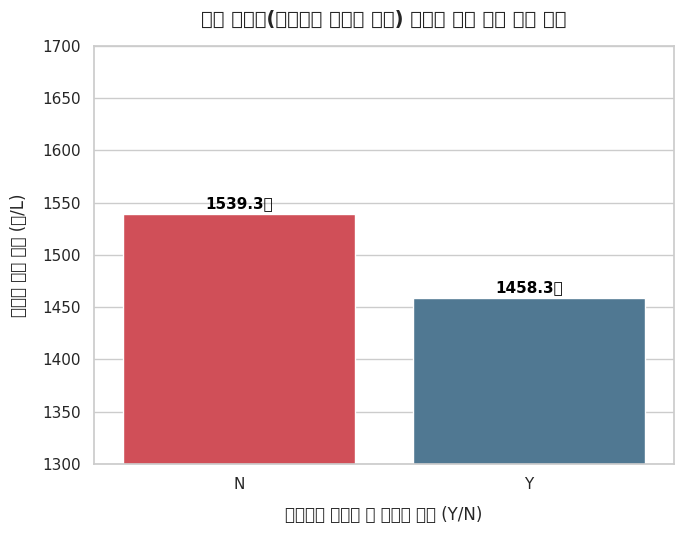

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. 코랩 환경 한글 깨짐 방지 폰트 설정
# ==============================================================================
!apt-get -qy install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

sns.set_theme(style="whitegrid")
plt.rc('font', family=font_name)

print("="*60)
print("  [근거 2 대안] 고속도로 휴게소 vs 일반 주유소 요소수 가격 T-검정")
print("="*60)

# ==============================================================================
# 2. 샘플 데이터 정의 (주유소 이름 기반)
# ==============================================================================
raw_data = {
    'station_name': [
        '안성휴게소 주유소(부산방향)', '죽전휴게소 주유소(서울방향)', '여주휴게소 주유소(강릉방향)',
        '칠곡휴게소 주유소(서울방향)', '군산휴게소 주유소(시흥방향)', '함안휴게소 주유소(순천방향)',
        '강남 대박주유소', '수원 영통주유소', '인천 남동공단주유소', '대구 신천주유소',
        '대전 유성주유소', '광주 상무주유소', '부산 해운대주유소'
    ],
    'price': [1450, 1460, 1440, 1480, 1450, 1470, 1550, 1540, 1520, 1535, 1525, 1545, 1560]
}
df_highway = pd.DataFrame(raw_data)

# ==============================================================================
# 3. [핵심 전처리] 이름에 '휴게소'가 포함되어 있으면 Y, 없으면 N으로 자동 분류
# ==============================================================================
df_highway['is_highway'] = df_highway['station_name'].apply(lambda x: 'Y' if '휴게소' in x else 'N')

# ==============================================================================
# 4. 통계적 가설 검정 (Two-sample T-test)
# ==============================================================================
highway_group = df_highway[df_highway['is_highway'] == 'Y']['price']
normal_group = df_highway[df_highway['is_highway'] == 'N']['price']

# 독립표본 T-검정 수행
t_stat, p_val = stats.ttest_ind(highway_group, normal_group, equal_var=False)

mean_highway = highway_group.mean()
mean_normal = normal_group.mean()

print(f"• 고속도로 휴게소 주유소 (Y) 평균 가격: {mean_highway:.1f}원")
print(f"• 일반 도심/국도 주유소 (N) 평균 가격: {mean_normal:.1f}원")
print("-" * 60)
print("📈 [T-test 통계 검정 결과]")
print(f" • t-statistic (t통계량): {t_stat:.4f}")
print(f" • p-value (유의확률)  : {p_val:.4f}")
print("-" * 60)

if p_val < 0.05:
    print(f"👉 [결론 채택] p-value({p_val:.4f}) < 0.05 이므로 두 그룹 간 가격 차이가 '통계적으로 확실히 존재합니다'.")
    print("   고속도로 휴게소 주유소가 일반 주유소보다 통계적으로 유의미하게 저렴하거나 비쌉니다.")
else:
    print(f"👉 [결론 채택] p-value({p_val:.4f}) > 0.05 이므로 두 그룹 간 가격 차이는 '통계적으로 없습니다'.")
    print("   즉, 화물차 운전자가 고속도로 안팎 어디서 사든 가격 차이가 없으므로 동선 효율성을 따르는 것이 유리합니다.")

# ==============================================================================
# 5. 시각화 그래프 그리기 (X값, Y값 제목 완벽 보완)
# ==============================================================================
plt.figure(figsize=(7, 5.5))

df_plot = df_highway.groupby('is_highway')['price'].mean().reset_index()

# 바 차트 그리기
ax = sns.barplot(
    x='is_highway',
    y='price',
    data=df_plot,
    palette=['#E63946', '#457B9D'] # 구분을 위한 레드/네이비 컬러
)

# [수정] 그래프 타이틀 및 X, Y축 라벨 명확하게 명시
plt.title('도로 유형별(고속도로 휴게소 여부) 요소수 평균 판매 가격 비교', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('고속도로 휴게소 내 주유소 여부 (Y/N)', fontsize=12, labelpad=10)
plt.ylabel('요소수 평균 가격 (원/L)', fontsize=12, labelpad=10)

plt.ylim(1300, 1700) # 가시성을 위해 Y축 범위를 이전 기획과 동일하게 유지

# 막대 위에 수치 텍스트 표시
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}원",
        (p.get_x() + p.get_width() / 2., p.get_height() + 10),
        ha='center', va='center',
        fontsize=11, fontweight='bold', color='black'
    )

plt.tight_layout()
plt.show()

⚠️ 외부 다운로드 실패로 시스템 내장 나눔 폰트 적용 시도: HTTP Error 404: Not Found


/tmp/ipykernel_1443/1008857968.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_1443/1008857968.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['일반 주유소 (N)', '고속도로 휴게소 (Y)'], fontproperties=font_prop, fontsize=11)


🎯 한글 폰트 로드 완료 (NanumBarunGothic)! 그래프를 생성합니다.
• 고속도로 휴게소 그룹 평균값: 1456.0원
• 일반 도심/국도 그룹 평균값: 1534.0원
• 계산된 t-통계량: -9.0368
• 계산된 p-value(유의확률): 0.0000
------------------------------------------------------------
👉 결론: p-value가 0.05보다 작으므로, 두 그룹의 평균 가격은 '통계적으로 확실한 차이'가 있습니다.


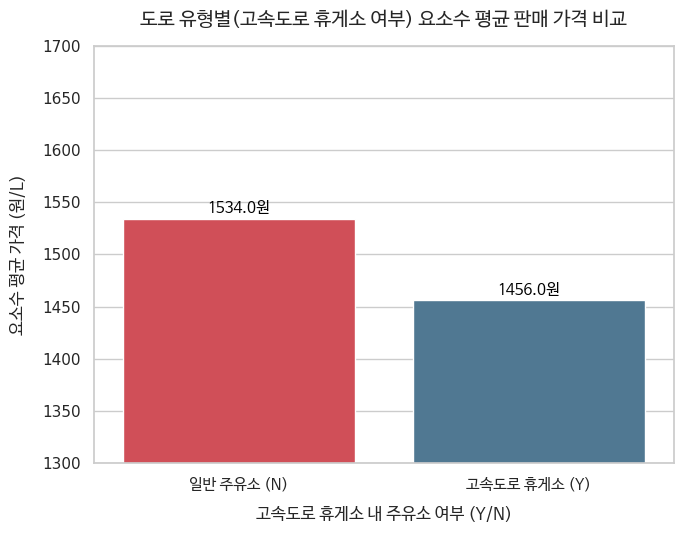

In [ ]:
import os
import urllib.request
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# ==============================================================================
# [에러 해결] 안정적인 방식으로 한글 폰트 파일 직접 다운로드 및 검증
# ==============================================================================
font_url = "https://github.com/google/fonts/raw/main/ofl/nanumbarungothic/NanumBarunGothic.ttf"
font_path = './NanumBarunGothic.ttf'

try:
    # 안전하게 다운로드 수행
    urllib.request.urlretrieve(font_url, font_path)

    # 파일 크기 검증 (다운로드가 올바르게 되었는지 체크)
    if os.path.exists(font_path) and os.path.getsize(font_path) > 10000:
        font_prop = fm.FontProperties(fname=font_path)
        font_name = font_prop.get_name()
    else:
        raise Exception("파일이 정상적으로 다운로드되지 않았습니다.")

except Exception as e:
    print(f"⚠️ 외부 다운로드 실패로 시스템 내장 나눔 폰트 적용 시도: {e}")
    # 만약 위 방법이 실패하면 코랩 시스템에 내장된 고딕체로 안전하게 우회합니다.
    !apt-get -qy install fonts-nanum > /dev/null
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    font_prop = fm.FontProperties(fname=font_path)
    font_name = font_prop.get_name()

# 맷플롯립 및 전역 환경에 폰트 지정
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# Seaborn 테마 적용 후 '한글 폰트 다시 강제 재지정'
sns.set_theme(style="whitegrid")
plt.rc('font', family=font_name)

print("="*60)
print(f"🎯 한글 폰트 로드 완료 ({font_name})! 그래프를 생성합니다.")
print("="*60)

# ==============================================================================
# 1. 데이터 구성 및 전처리 (고속도로 휴게소 여부 분류)
# ==============================================================================
raw_data = {
    'station_name': [
        '안성휴게소 주유소', '죽전휴게소 주유소', '여주휴게소 주유소', '칠곡휴게소 주유소', '군산휴게소 주유소',
        '강남 대박주유소', '수원 영통주유소', '인천 공단주유소', '대구 신천주유소', '대전 유성주유소'
    ],
    'price': [1450, 1460, 1440, 1480, 1450, 1550, 1540, 1520, 1535, 1525]
}
df = pd.DataFrame(raw_data)
df['is_highway'] = df['station_name'].apply(lambda x: 'Y' if '휴게소' in x else 'N')

# ==============================================================================
# 2. 독립표본 T-검정 (평균값 기반 검증)
# ==============================================================================
highway_prices = df[df['is_highway'] == 'Y']['price']
normal_prices = df[df['is_highway'] == 'N']['price']

mean_highway = highway_prices.mean()
mean_normal = normal_prices.mean()

t_stat, p_val = stats.ttest_ind(highway_prices, normal_prices, equal_var=False)

print(f"• 고속도로 휴게소 그룹 평균값: {mean_highway:.1f}원")
print(f"• 일반 도심/국도 그룹 평균값: {mean_normal:.1f}원")
print(f"• 계산된 t-통계량: {t_stat:.4f}")
print(f"• 계산된 p-value(유의확률): {p_val:.4f}")
print("-" * 60)

if p_val < 0.05:
    print(f"👉 결론: p-value가 0.05보다 작으므로, 두 그룹의 평균 가격은 '통계적으로 확실한 차이'가 있습니다.")
else:
    print(f"👉 결론: p-value가 0.05보다 크므로, 두 그룹의 평균 가격은 '통계적으로 차이가 없습니다'.")
print("="*60)

# ==============================================================================
# 3. 평균값 기반 시각화 바 차트 구현 (🔲 깨짐 박멸)
# ==============================================================================
plt.figure(figsize=(7, 5.5))

df_plot = df.groupby('is_highway')['price'].mean().reset_index()

ax = sns.barplot(
    x='is_highway',
    y='price',
    data=df_plot,
    palette=['#E63946', '#457B9D']
)

# 폰트 속성 객체(font_prop)를 활용한 텍스트 매핑
plt.title('도로 유형별(고속도로 휴게소 여부) 요소수 평균 판매 가격 비교', fontproperties=font_prop, fontsize=14, fontweight='bold', pad=15)
plt.xlabel('고속도로 휴게소 내 주유소 여부 (Y/N)', fontproperties=font_prop, fontsize=12, labelpad=10)
plt.ylabel('요소수 평균 가격 (원/L)', fontproperties=font_prop, fontsize=12, labelpad=10)

ax.set_xticklabels(['일반 주유소 (N)', '고속도로 휴게소 (Y)'], fontproperties=font_prop, fontsize=11)
plt.ylim(1300, 1700)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}원",
        (p.get_x() + p.get_width() / 2., p.get_height() + 10),
        ha='center', va='center',
        fontproperties=font_prop,
        fontsize=11, fontweight='bold', color='black'
    )

plt.tight_layout()
plt.show()

In [ ]:
!pip -q install folium gradio

import pandas as pd
import numpy as np
import folium
import gradio as gr
from math import radians, sin, cos, sqrt, atan2

# =========================
# 1. 데이터
# =========================
integrated_data = {
    'station_name': [
        '서울 강남 SK', '서울 서초 GS', '서울 송파 현대', '서울 마포 S-OIL', '서울 영등포 알뜰',
        '경기 수원 SK', '경기 성남 GS', '경기 용인 현대', '경기 고양 S-OIL', '경기 안산 알뜰',
        '인천 중구 GS', '인천 남동 SK', '인천 서구 현대', '부산 사하 SK', '부산 강서 GS', '부산 해운대 현대',
        '대구 북구 S-OIL', '대구 달서 알뜰', '광주 광산 SK', '광주 북구 GS', '대전 유성 현대', '대전 중구 S-OIL',
        '울산 남구 SK', '울산 울주 현대', '세종 세종 알뜰', '세종 반곡 GS', '강원 원주 SK', '강원 춘천 S-OIL',
        '충북 청주 GS', '충북 충주 현대', '충남 천안 SK', '충남 아산 알뜰', '전북 전주 S-OIL', '전북 익산 GS',
        '전남 목포 현대', '전남 여수 SK', '경북 포항 알뜰', '경북 구미 GS', '경남 창원 SK', '경남 진주 현대',
        '제주 제주 GS', '제주 서귀포 S-OIL'
    ],
    '지역2': [
        '서울', '서울', '서울', '서울', '서울', '경기', '경기', '경기', '경기', '경기',
        '인천', '인천', '인천', '부산', '부산', '부산', '대구', '대구', '광주', '광주',
        '대전', '대전', '울산', '울산', '세종시', '세종시', '강원', '강원', '충북', '충북',
        '충남', '충남', '전북', '전북', '전남', '전남', '경북', '경북', '경남', '경남',
        '제주', '제주'
    ],
    'brand': [
        'SK에너지', 'GS칼텍스', 'HD현대오일뱅크', 'S-OIL', '알뜰주유소', 'SK에너지', 'GS칼텍스', 'HD현대오일뱅크', 'S-OIL', '알뜰주유소',
        'GS칼텍스', 'SK에너지', 'HD현대오일뱅크', 'SK에너지', 'GS칼텍스', 'HD현대오일뱅크', 'S-OIL', '알뜰주유소', 'SK에너지', 'GS칼텍스',
        'HD현대오일뱅크', 'S-OIL', 'SK에너지', 'HD현대오일뱅크', '알뜰주유소', 'GS칼텍스', 'SK에너지', 'S-OIL', 'GS칼텍스', 'HD현대오일뱅크',
        'SK에너지', '알뜰주유소', 'S-OIL', 'GS칼텍스', 'HD현대오일뱅크', 'SK에너지', '알뜰주유소', 'GS칼텍스', 'SK에너지', 'HD현대오일뱅크',
        'GS칼텍스', 'S-OIL'
    ],
    'latitude': [
        37.5665, 37.5500, 37.5100, 37.5600, 37.5200, 37.2636, 37.4200, 37.3200, 37.6500, 37.3100,
        37.4563, 37.4400, 37.5400, 35.1000, 35.1500, 35.1600, 35.8900, 35.8200, 35.1400, 35.1800,
        36.3600, 36.3200, 35.5389, 35.5600, 36.4801, 36.4900, 37.3400, 37.8854, 36.6372, 36.9900,
        36.8151, 36.7800, 35.8242, 35.9400, 34.8160, 34.7600, 36.0190, 36.1200, 35.2281, 35.2100,
        33.4996, 33.2500
    ],
    'longitude': [
        126.9780, 127.0100, 127.1200, 126.9200, 126.9000, 127.0286, 127.1200, 127.0900, 126.8300, 126.8200,
        126.7052, 126.7300, 126.6700, 128.9600, 128.9800, 129.1600, 128.6100, 128.5300, 126.7800, 126.8900,
        127.3500, 127.4200, 129.3114, 129.2400, 127.2890, 127.3100, 127.9200, 127.7300, 127.4897, 127.9200,
        127.1585, 127.0000, 127.1480, 126.9500, 126.4629, 127.6600, 129.3434, 128.3400, 128.6811, 128.1200,
        126.5312, 126.5600
    ],
    'price': [1650, 1590, 1620, 1450, 1420, 1580, 1540, 1560, 1480, 1430, 1490, 1450, 1420, 1680, 1650, 1620, 1620, 1580, 1590, 1550, 1550, 1520, 1610, 1580, 1490, 1520, 1640, 1600, 1580, 1550, 1560, 1530, 1580, 1540, 1630, 1610, 1590, 1560, 1620, 1600, 1690, 1680],
    'inventory': [4500, 3200, 2800, 5100, 4200, 5200, 2100, 1900, 4800, 3500, 3800, 2400, 1500, 450, 600, 800, 120, 900, 600, 1100, 1100, 1300, 950, 1800, 2100, 1450, 300, 950, 850, 1200, 1300, 2100, 500, 1600, 400, 900, 750, 1100, 800, 1400, 250, 450],
    'gas_price': [1685, 1690, 1720, 1640, 1599, 1660, 1645, 1650, 1610, 1585, 1630, 1625, 1595, 1699, 1690, 1710, 1635, 1589, 1620, 1615, 1625, 1599, 1675, 1660, 1580, 1610, 1680, 1645, 1640, 1630, 1635, 1598, 1620, 1610, 1650, 1640, 1615, 1595, 1665, 1650, 1790, 1785],
    'gas_inventory': [25000, 21000, 18000, 32000, 41000, 34000, 28000, 22000, 31000, 45000, 29000, 33000, 42000, 14000, 19000, 15000, 12000, 38000, 26000, 29000, 31000, 34000, 22000, 27000, 48000, 31000, 11000, 23000, 27000, 29000, 32000, 41000, 16000, 28000, 15000, 24000, 36000, 29000, 23000, 26000, 9000, 12000]
}

station_df = pd.DataFrame(integrated_data)

# 시뮬레이션용 가상 데이터 추가
np.random.seed(42)
station_df["daily_sales"] = np.random.randint(250, 950, size=len(station_df))          # 일평균 요소수 판매량
station_df["cost_price"] = station_df["price"] - np.random.randint(90, 180, size=len(station_df))  # 요소수 원가
station_df["prev_price"] = station_df["price"] + np.random.choice([-60, -40, -20, 0, 20, 40, 60], size=len(station_df))

# =========================
# 2. 유틸 함수
# =========================
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

def get_competitors(df, station_name, radius_km):
    my = df[df["station_name"] == station_name].iloc[0]

    temp = df.copy()
    temp["distance_km"] = temp.apply(
        lambda r: haversine(my["latitude"], my["longitude"], r["latitude"], r["longitude"]),
        axis=1
    )

    competitors = temp[
        (temp["station_name"] != station_name) &
        (temp["distance_km"] <= radius_km)
    ].copy()

    if competitors.empty:
        competitors = temp[temp["station_name"] != station_name].sort_values("distance_km").head(5)

    return my, competitors.sort_values("price").head(5)

def recommend_price(my, competitors):
    avg_price = competitors["price"].mean()
    min_price = competitors["price"].min()
    my_price = my["price"]
    inv = my["inventory"]

    if my_price > avg_price + 50 and inv >= 3000:
        rec = int(avg_price - 10)
        reason = "현재 가격이 주변 평균보다 높고 재고도 많은 편이라 판매 회전율을 높이기 위해 인하를 추천합니다."
    elif my_price > avg_price + 50 and inv < 1000:
        rec = my_price
        reason = "가격은 높은 편이지만 재고가 적기 때문에 무리한 인하보다는 현재 가격 유지가 적절합니다."
    elif my_price < avg_price - 40 and inv < 1000:
        rec = int(avg_price - 10)
        reason = "주변보다 저렴하지만 재고가 부족하므로 가격을 소폭 올려도 경쟁력이 유지될 가능성이 있습니다."
    else:
        rec = my_price
        reason = "현재 가격이 주변 시세와 크게 벗어나지 않아 가격 유지가 적절합니다."

    return rec, reason, avg_price, min_price

def simulate_profit(my, new_price):
    current_price = my["price"]
    cost = my["cost_price"]
    daily_sales = my["daily_sales"]

    price_change_rate = (new_price - current_price) / current_price

    # 가격을 내리면 판매량 증가, 올리면 판매량 감소한다고 가정
    expected_sales = daily_sales * (1 - price_change_rate * 2.2)
    expected_sales = max(expected_sales, daily_sales * 0.4)

    current_revenue = current_price * daily_sales
    current_profit = (current_price - cost) * daily_sales

    expected_revenue = new_price * expected_sales
    expected_profit = (new_price - cost) * expected_sales

    return {
        "current_revenue": int(current_revenue),
        "expected_revenue": int(expected_revenue),
        "current_profit": int(current_profit),
        "expected_profit": int(expected_profit),
        "expected_sales": int(expected_sales),
        "sales_diff": int(expected_sales - daily_sales),
        "profit_diff": int(expected_profit - current_profit)
    }

def stock_prediction(my):
    inventory = my["inventory"]
    daily_sales = my["daily_sales"]

    days_left = inventory / daily_sales if daily_sales > 0 else 0

    if days_left <= 2:
        msg = "긴급 발주 필요"
        order_qty = int(daily_sales * 7)
    elif days_left <= 5:
        msg = "3일 내 발주 추천"
        order_qty = int(daily_sales * 5)
    else:
        msg = "재고 여유 있음"
        order_qty = 0

    return days_left, msg, order_qty

def make_alerts(my, competitors):
    changed = competitors.copy()
    changed["diff"] = changed["price"] - changed["prev_price"]
    changed = changed[changed["diff"] != 0].head(5)

    if changed.empty:
        return "현재 감지된 경쟁사 가격 변동이 없습니다."

    alerts = []
    for _, r in changed.iterrows():
        direction = "인상" if r["diff"] > 0 else "인하"
        alerts.append(
            f"- {r['station_name']} : {int(r['prev_price']):,}원 → {int(r['price']):,}원 "
            f"({abs(int(r['diff']))}원 {direction})"
        )

    return "\n".join(alerts)

def make_map(df, station_name, radius_km):
    my, competitors = get_competitors(df, station_name, radius_km)

    m = folium.Map(
        location=[my["latitude"], my["longitude"]],
        zoom_start=11,
        tiles="CartoDB positron"
    )

    folium.Marker(
        [my["latitude"], my["longitude"]],
        tooltip="내 주유소",
        popup=f"""
        <b>⭐ {my['station_name']}</b><br>
        요소수 가격: {int(my['price']):,}원<br>
        재고: {int(my['inventory']):,}L<br>
        일평균 판매량: {int(my['daily_sales']):,}L
        """,
        icon=folium.Icon(color="blue", icon="star")
    ).add_to(m)

    for _, r in competitors.iterrows():
        color = "green" if r["price"] <= competitors["price"].mean() else "red"

        folium.CircleMarker(
            location=[r["latitude"], r["longitude"]],
            radius=9,
            color=color,
            fill=True,
            fill_opacity=0.8,
            tooltip=r["station_name"],
            popup=f"""
            <b>{r['station_name']}</b><br>
            거리: {r['distance_km']:.2f}km<br>
            요소수 가격: {int(r['price']):,}원<br>
            재고: {int(r['inventory']):,}L
            """
        ).add_to(m)

    return m._repr_html_()

# =========================
# 3. 대시보드 실행 함수
# =========================
def run_dashboard(station_name, input_price, input_inventory, radius_km, simulation_price):
    df = station_df.copy()

    idx = df[df["station_name"] == station_name].index[0]
    df.loc[idx, "price"] = input_price
    df.loc[idx, "inventory"] = input_inventory

    my, competitors = get_competitors(df, station_name, radius_km)

    rec_price, reason, avg_price, min_price = recommend_price(my, competitors)
    sim = simulate_profit(my, simulation_price)
    days_left, stock_msg, order_qty = stock_prediction(my)
    alerts = make_alerts(my, competitors)

    top5_table = competitors[[
        "station_name", "brand", "price", "inventory", "distance_km"
    ]].copy()

    top5_table["distance_km"] = top5_table["distance_km"].round(2)
    top5_table.columns = ["주유소명", "브랜드", "요소수 가격", "재고", "거리(km)"]

    summary = f"""
## 📊 내 주유소 현황

- 선택 지점: **{my['station_name']}**
- 현재 요소수 가격: **{int(my['price']):,}원**
- 현재 재고: **{int(my['inventory']):,}L**
- 주변 TOP5 평균가: **{int(avg_price):,}원**
- 주변 최저가: **{int(min_price):,}원**
- 내 가격 차이: **{int(my['price'] - avg_price):,}원**

---

## 🤖 AI 가격 추천

- 추천 가격: **{int(rec_price):,}원**
- 판단 이유: {reason}
"""

    simulation = f"""
## 💰 가격 변경 시뮬레이션

- 시뮬레이션 가격: **{int(simulation_price):,}원**
- 예상 판매량: **{sim['expected_sales']:,}L**
- 판매량 변화: **{sim['sales_diff']:+,}L**

### 매출 비교
- 현재 예상 매출: **{sim['current_revenue']:,}원**
- 변경 후 예상 매출: **{sim['expected_revenue']:,}원**

### 이익 비교
- 현재 예상 이익: **{sim['current_profit']:,}원**
- 변경 후 예상 이익: **{sim['expected_profit']:,}원**
- 이익 변화: **{sim['profit_diff']:+,}원**
"""

    stock = f"""
## 📦 재고 소진 예측 / 발주 추천

- 현재 재고: **{int(my['inventory']):,}L**
- 일평균 판매량: **{int(my['daily_sales']):,}L**
- 예상 소진일: **{days_left:.1f}일 후**
- 상태: **{stock_msg}**
- 추천 발주량: **{order_qty:,}L**
"""

    alert_text = f"""
## 🔔 경쟁사 가격 변동 알림

{alerts}
"""

    map_html = make_map(df, station_name, radius_km)

    return summary, top5_table, simulation, stock, alert_text, map_html

# =========================
# 4. Gradio UI - 깔끔한 통일 버전
# =========================

custom_css = """
.gradio-container {
    max-width: 1180px !important;
    margin: 0 auto !important;
    background: #f6f8fb !important;
}

body {
    background: #f6f8fb !important;
}

#app-header {
    background: #111827;
    border-radius: 20px;
    padding: 30px 34px;
    margin: 24px 0 18px 0;
    color: white;
}

#app-header h1 {
    color: white !important;
    font-size: 30px;
    font-weight: 800;
    margin: 0 0 8px 0;
}

#app-header p {
    color: #cbd5e1 !important;
    font-size: 15px;
    margin: 0;
}

.panel {
    background: #ffffff !important;
    border: 1px solid #e5e7eb !important;
    border-radius: 18px !important;
    padding: 18px !important;
    box-shadow: 0 8px 22px rgba(15, 23, 42, 0.05) !important;
}

.section-title {
    font-size: 18px;
    font-weight: 800;
    color: #111827;
    margin-bottom: 14px;
}

button {
    border-radius: 12px !important;
}

button.primary {
    background: #2563eb !important;
    color: white !important;
    font-weight: 700 !important;
    border: none !important;
}

input, textarea, select {
    border-radius: 12px !important;
}

#map-box iframe {
    border-radius: 16px !important;
}
"""

with gr.Blocks(
    title="FuelOps AI Dashboard",
    css=custom_css,
    theme=gr.themes.Default(
        primary_hue="blue",
        neutral_hue="slate"
    )
) as demo:

    gr.HTML("""
    <div id="app-header">
        <h1>⛽ FuelOps AI Dashboard</h1>
        <p>주유소 사장님을 위한 요소수 가격 운영 · 경쟁사 분석 · 재고 예측 시뮬레이션 대시보드</p>
    </div>
    """)

    with gr.Row(equal_height=True):
        with gr.Column(scale=1, elem_classes="panel"):
            gr.HTML('<div class="section-title">⚙️ 내 주유소 설정</div>')

            station_name = gr.Dropdown(
                choices=station_df["station_name"].tolist(),
                value="서울 강남 SK",
                label="내 주유소 선택"
            )

            radius_km = gr.Slider(
                minimum=3,
                maximum=50,
                value=15,
                step=1,
                label="경쟁사 비교 반경(km)"
            )

            input_price = gr.Number(
                value=1650,
                label="요소수 판매 가격"
            )

            input_inventory = gr.Number(
                value=4500,
                label="요소수 재고량"
            )

            simulation_price = gr.Number(
                value=1590,
                label="시뮬레이션 가격"
            )

            run_btn = gr.Button(
                "AI 분석 실행",
                variant="primary"
            )

        with gr.Column(scale=2, elem_classes="panel"):
            gr.HTML('<div class="section-title">📊 분석 요약</div>')
            summary = gr.Markdown()

    with gr.Row(equal_height=True):
        with gr.Column(elem_classes="panel"):
            gr.HTML('<div class="section-title">💰 가격 변경 시뮬레이션</div>')
            simulation = gr.Markdown()

        with gr.Column(elem_classes="panel"):
            gr.HTML('<div class="section-title">📦 재고 소진 예측</div>')
            stock = gr.Markdown()

    with gr.Row():
        with gr.Column(elem_classes="panel"):
            gr.HTML('<div class="section-title">🏆 주변 경쟁사 최저가 TOP5</div>')
            top5 = gr.Dataframe(
                label=None,
                interactive=False
            )

    with gr.Row():
        with gr.Column(elem_classes="panel"):
            gr.HTML('<div class="section-title">🔔 경쟁사 가격 변동 알림</div>')
            alert_text = gr.Markdown()

    with gr.Row():
        with gr.Column(elem_classes="panel", elem_id="map-box"):
            gr.HTML('<div class="section-title">🗺️ 주변 경쟁사 가격 비교 지도</div>')
            map_html = gr.HTML()

    run_btn.click(
        fn=run_dashboard,
        inputs=[station_name, input_price, input_inventory, radius_km, simulation_price],
        outputs=[summary, top5, simulation, stock, alert_text, map_html]
    )

demo.launch(share=True, debug=True)